<a href="https://colab.research.google.com/github/ElijahLewisUWI/COMP3610-A3/blob/main/Top_movies_analysis_A1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Jadon Felix** *816036756*
- **Assignment 1**
- *Part*

# **Top Hollywood Movies**

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving top_hollywood_grossing_movies.csv to top_hollywood_grossing_movies.csv


In [3]:
df = pd.read_csv("top_hollywood_grossing_movies.csv")

In [4]:
df.head()

,Unnamed: 0,Title,Movie Info,Distributor,Release Date,Domestic Sales (in $),International Sales (in $),World Sales (in $),Genre,Movie Runtime,License
0,0,Star Wars: Episode VII - The Force Awakens (2015),"As a new threat to the galaxy rises, Rey, a de...",Walt Disney Studios Motion Pictures,"December 16, 2015",936662225,1132859475,2069521700,"['Action', 'Adventure', 'Sci-Fi']",2 hr 18 min,PG-13
1,1,Avengers: Endgame (2019),After the devastating events of Avengers: Infi...,Walt Disney Studios Motion Pictures,"April 24, 2019",858373000,1939128328,2797501328,"['Action', 'Adventure', 'Drama', 'Sci-Fi']",3 hr 1 min,PG-13
2,2,Avatar (2009),A paraplegic Marine dispatched to the moon Pan...,Twentieth Century Fox,"December 16, 2009",760507625,2086738578,2847246203,"['Action', 'Adventure', 'Fantasy', 'Sci-Fi']",2 hr 42 min,PG-13
3,3,Black Panther (2018),"T'Challa, heir to the hidden but advanced king...",Walt Disney Studios Motion Pictures,NaN,700426566,647171407,1347597973,"['Action', 'Adventure', 'Sci-Fi']",2 hr 14 min,NaN
4,4,Avengers: Infinity War (2018),The Avengers and their allies must be willing ...,Walt Disney Studios Motion Pictures,NaN,678815482,1369544272,2048359754,"['Action', 'Adventure', 'Sci-Fi']",2 hr 29 min,NaN


In [5]:
df = df.drop(columns=['Unnamed: 0'])
df.head()

,Title,Movie Info,Distributor,Release Date,Domestic Sales (in $),International Sales (in $),World Sales (in $),Genre,Movie Runtime,License
0,Star Wars: Episode VII - The Force Awakens (2015),"As a new threat to the galaxy rises, Rey, a de...",Walt Disney Studios Motion Pictures,"December 16, 2015",936662225,1132859475,2069521700,"['Action', 'Adventure', 'Sci-Fi']",2 hr 18 min,PG-13
1,Avengers: Endgame (2019),After the devastating events of Avengers: Infi...,Walt Disney Studios Motion Pictures,"April 24, 2019",858373000,1939128328,2797501328,"['Action', 'Adventure', 'Drama', 'Sci-Fi']",3 hr 1 min,PG-13
2,Avatar (2009),A paraplegic Marine dispatched to the moon Pan...,Twentieth Century Fox,"December 16, 2009",760507625,2086738578,2847246203,"['Action', 'Adventure', 'Fantasy', 'Sci-Fi']",2 hr 42 min,PG-13
3,Black Panther (2018),"T'Challa, heir to the hidden but advanced king...",Walt Disney Studios Motion Pictures,NaN,700426566,647171407,1347597973,"['Action', 'Adventure', 'Sci-Fi']",2 hr 14 min,NaN
4,Avengers: Infinity War (2018),The Avengers and their allies must be willing ...,Walt Disney Studios Motion Pictures,NaN,678815482,1369544272,2048359754,"['Action', 'Adventure', 'Sci-Fi']",2 hr 29 min,NaN


###**Sumary Statistics**

1. Size of DataFrame

In [6]:
df.shape

(900, 10)

2. Column Datatypes

In [7]:
df.dtypes

,0
Title,object
Movie Info,object
Distributor,object
Release Date,object
Domestic Sales (in $),int64
International Sales (in $),int64
World Sales (in $),int64
Genre,object
Movie Runtime,object
License,object


3. No. of empty cells in DataFrame

In [8]:
df.isna().sum()

,0
Title,0
Movie Info,0
Distributor,0
Release Date,202
Domestic Sales (in $),0
International Sales (in $),0
World Sales (in $),0
Genre,0
Movie Runtime,0
License,171


###**Data Cleaning**

!. Dealing with Missing Values

In [9]:
df.fillna("X").all()

,0
Title,True
Movie Info,True
Distributor,True
Release Date,True
Domestic Sales (in $),True
International Sales (in $),True
World Sales (in $),True
Genre,True
Movie Runtime,True
License,True


**Note:**
- Considerations were made to utalize the mean and mode values as is common pracctice with respect to dealing with missing values in the DataFrame. However this was judged to be inaccurate, due to the missing values being in the "Release Dare" and "License" indicate a strong uniqueness component that cannot be substittuted with mode or popular values, thus they were ignored and simply replaced with "X"

2. Converting Movie Length

In [10]:
def convert_to_minutes(time_str):
    time_str = time_str.strip()   # Temoving white spaces within cell
    parts = time_str.split()      # Extracting the component text in the cell

    # Initializing the time components
    hours = 0
    minutes = 0

    # Extracting the numerical values from the components
    if "hr" in time_str:
        hours = int(parts[0])
    if "min" in time_str:
        minutes = int(parts[2])

    return hours * 60 + minutes

In [11]:
df['Movie Runtime (in mins)'] = df['Movie Runtime'].apply(convert_to_minutes)
df[['Title', 'Movie Runtime (in mins)']]

,Title,Movie Runtime (in mins)
0,Star Wars: Episode VII - The Force Awakens (2015),138
1,Avengers: Endgame (2019),181
2,Avatar (2009),162
3,Black Panther (2018),134
4,Avengers: Infinity War (2018),149
...,...,...
895,Beowulf (2007),115
896,Bridge to Terabithia (2007),96
897,The Pink Panther (2006),93
898,Teenage Mutant Ninja Turtles: Out of the Shado...,112


##**Data Analysis**

1. Movie Release Dates

In [12]:
# Convert the 'Release Date' column to datetime format
df['Release Date'] = pd.to_datetime(df['Release Date'])

# Then extract the month name
df['Release Month'] = df['Release Date'].dt.month_name()

In [13]:
month_data = df['Release Month'].dropna()

df['Release Month'].value_counts().head(5)

,count
Release Month,
June,111
December,104
July,87
May,81
November,79


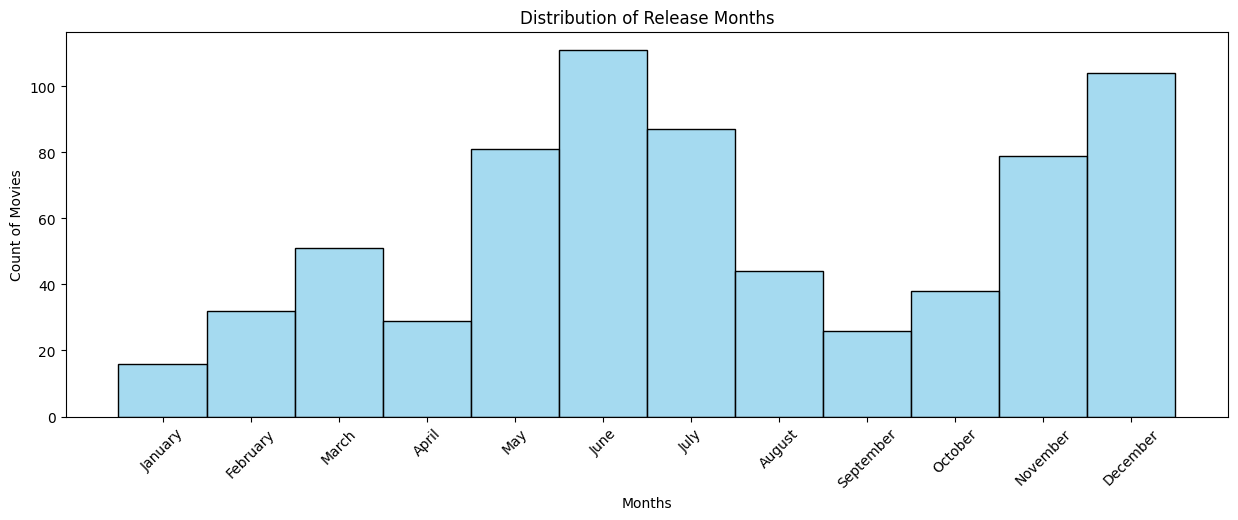

In [14]:
# Order the months chronologically
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
month_data_ordered = pd.Categorical(month_data, categories=month_order, ordered=True)

plt.figure(figsize=(15, 5))
ax = sns.histplot(data=month_data_ordered,
                  bins=12,  # One bin per month
                  stat='count',
                  color='skyblue',
                  edgecolor='black')

plt.title('Distribution of Release Months')
plt.xlabel('Months')
plt.ylabel('Count of Movies')
plt.xticks(rotation=45)
plt.show()

In [15]:
df['Release Year'] = df['Release Date'].dt.year

<Axes: xlabel='Release Year'>

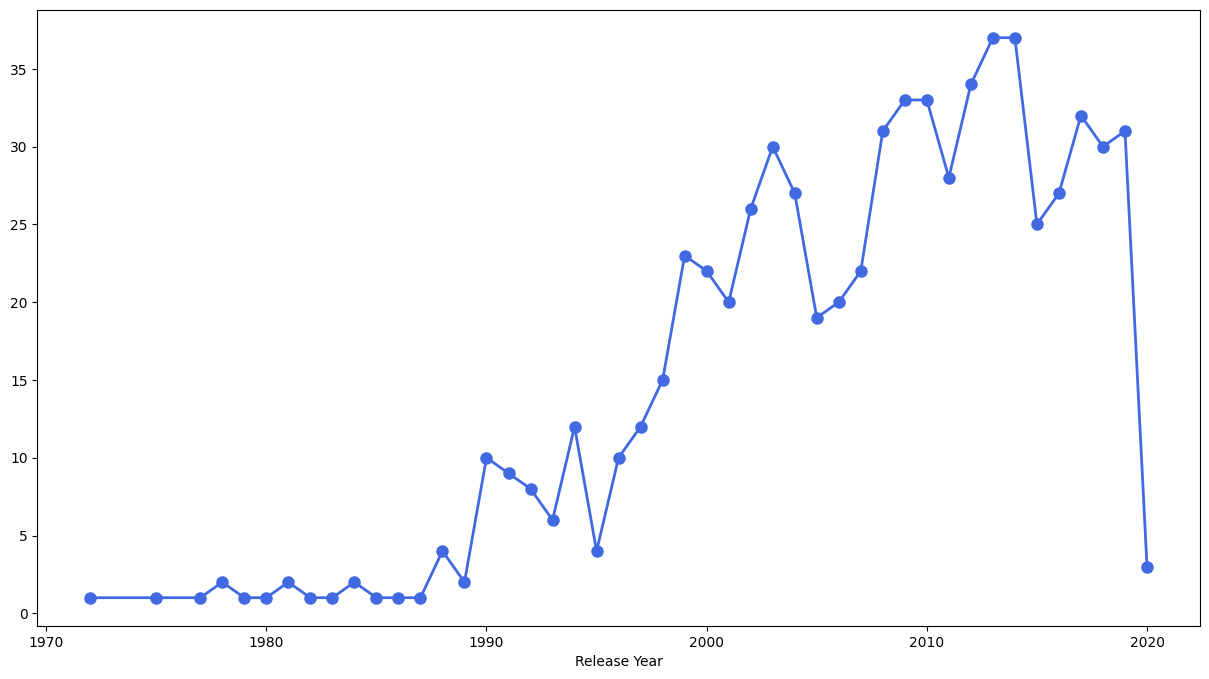

In [16]:
year_counts = df['Release Year'].dropna().value_counts().sort_index()


plt.figure(figsize=(15, 8))
year_counts.plot(kind='line',
                marker='o',
                color='royalblue',
                linewidth=2,
                markersize=8)

### The Major Movie Distributors

By number of movies distributed we determine the top 5 major or most previlent didtributers

In [17]:
df['Distributor'].value_counts().head(5)

,count
Distributor,
Warner Bros.,158
Walt Disney Studios Motion Pictures,152
Universal Pictures,118
Twentieth Century Fox,113
Sony Pictures Entertainment (SPE),98


In [18]:
distribution_percent = (df['Distributor'].value_counts().head(5).sum()/df['Distributor'].value_counts().sum())*100
print(f"Therefore, the Top 5 Movie Distributors account for {distribution_percent:.1f}% of all movies distributed")

Therefore, the Top 5 Movie Distributors account for 71.0% of all movies distributed


/tmp/ipython-input-533992983.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=distributor_sales.index, y=distributor_sales.values, palette='viridis')


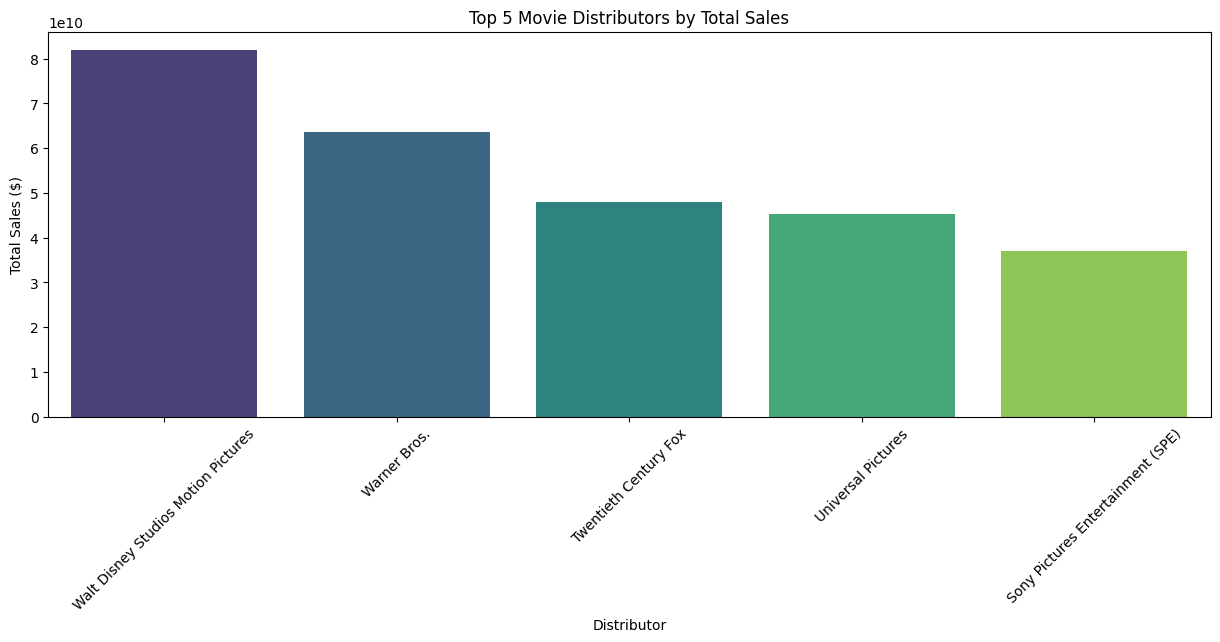

In [19]:
distributor_sales = df.groupby('Distributor')['World Sales (in $)'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(15, 5))
sns.barplot(x=distributor_sales.index, y=distributor_sales.values, palette='viridis')
plt.title('Top 5 Movie Distributors by Total Sales')
plt.xlabel('Distributor')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.show()

### **Domestic v.s International Movie Box Office Sales**

In [20]:
df[['Title', 'Domestic Sales (in $)', 'International Sales (in $)']].head()

,Title,Domestic Sales (in $),International Sales (in $)
0,Star Wars: Episode VII - The Force Awakens (2015),936662225,1132859475
1,Avengers: Endgame (2019),858373000,1939128328
2,Avatar (2009),760507625,2086738578
3,Black Panther (2018),700426566,647171407
4,Avengers: Infinity War (2018),678815482,1369544272


<Axes: title={'center': 'Top Movies by Worldwide Sales'}, ylabel='Title'>

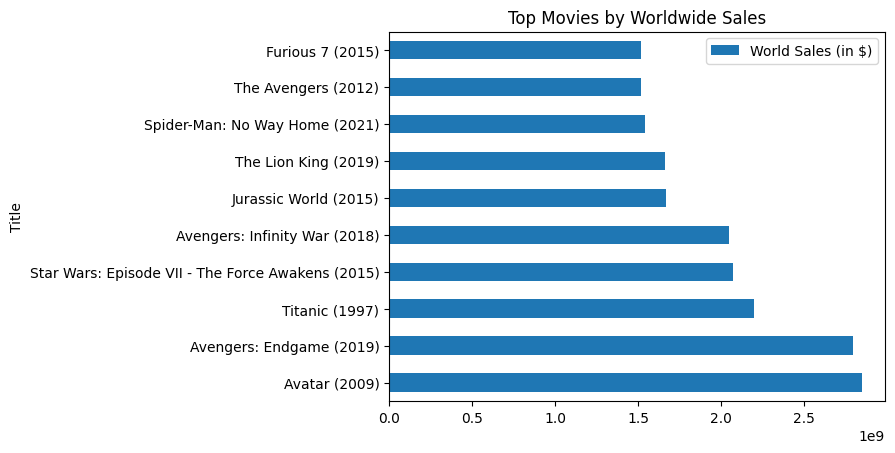

In [21]:
df.sort_values('World Sales (in $)', ascending=False).head(10).plot.barh(
    x='Title', y='World Sales (in $)',
    title='Top Movies by Worldwide Sales'
)

In [22]:
df['Dom v.s Int Sales'] = df['Domestic Sales (in $)'] - df['International Sales (in $)']

In [23]:
df_rsm = df[(df['Dom v.s Int Sales'] > 0)]
df_im = df[(df['Dom v.s Int Sales'] < 0)]

In [24]:
df_rsm.head()

,Title,Movie Info,Distributor,Release Date,Domestic Sales (in $),International Sales (in $),World Sales (in $),Genre,Movie Runtime,License,Movie Runtime (in mins),Release Month,Release Year,Dom v.s Int Sales
3,Black Panther (2018),"T'Challa, heir to the hidden but advanced king...",Walt Disney Studios Motion Pictures,NaT,700426566,647171407,1347597973,"['Action', 'Adventure', 'Sci-Fi']",2 hr 14 min,NaN,134,NaN,NaN,53255159
12,The Dark Knight (2008),When the menace known as the Joker wreaks havo...,Warner Bros.,2008-07-16,534858444,471115201,1005973645,"['Action', 'Crime', 'Drama', 'Thriller']",2 hr 32 min,PG-13,152,July,2008.0,63743243
13,Rogue One: A Star Wars Story (2016),"In a time of conflict, a group of unlikely her...",Walt Disney Studios Motion Pictures,2016-12-14,532177324,523880396,1056057720,"['Action', 'Adventure', 'Sci-Fi']",2 hr 13 min,PG-13,133,December,2016.0,8296928
19,Star Wars: Episode IV - A New Hope (1977),Luke Skywalker joins forces with a Jedi Knight...,Twentieth Century Fox,1977-05-25,460998507,195751992,775398007,"['Action', 'Adventure', 'Fantasy', 'Sci-Fi']",2 hr 1 min,PG,121,May,1977.0,265246515
23,E.T. the Extra-Terrestrial (1982),A troubled child summons the courage to help a...,Universal Pictures,1982-06-11,435110554,304203888,792910554,"['Adventure', 'Family', 'Sci-Fi']",1 hr 55 min,PG,115,June,1982.0,130906666


In [25]:
df_im.head()

,Title,Movie Info,Distributor,Release Date,Domestic Sales (in $),International Sales (in $),World Sales (in $),Genre,Movie Runtime,License,Movie Runtime (in mins),Release Month,Release Year,Dom v.s Int Sales
0,Star Wars: Episode VII - The Force Awakens (2015),"As a new threat to the galaxy rises, Rey, a de...",Walt Disney Studios Motion Pictures,2015-12-16,936662225,1132859475,2069521700,"['Action', 'Adventure', 'Sci-Fi']",2 hr 18 min,PG-13,138,December,2015.0,-196197250
1,Avengers: Endgame (2019),After the devastating events of Avengers: Infi...,Walt Disney Studios Motion Pictures,2019-04-24,858373000,1939128328,2797501328,"['Action', 'Adventure', 'Drama', 'Sci-Fi']",3 hr 1 min,PG-13,181,April,2019.0,-1080755328
2,Avatar (2009),A paraplegic Marine dispatched to the moon Pan...,Twentieth Century Fox,2009-12-16,760507625,2086738578,2847246203,"['Action', 'Adventure', 'Fantasy', 'Sci-Fi']",2 hr 42 min,PG-13,162,December,2009.0,-1326230953
4,Avengers: Infinity War (2018),The Avengers and their allies must be willing ...,Walt Disney Studios Motion Pictures,NaT,678815482,1369544272,2048359754,"['Action', 'Adventure', 'Sci-Fi']",2 hr 29 min,NaN,149,NaN,NaN,-690728790
5,Spider-Man: No Way Home (2021),"With Spider-Man's identity now revealed, Peter...",Sony Pictures Entertainment (SPE),NaT,675813257,868642706,1544455963,"['Action', 'Adventure', 'Fantasy', 'Sci-Fi']",2 hr 28 min,NaN,148,NaN,NaN,-192829449


**Domestic Movie**

Assuming that the listed movie is a domestic movie is based on tthe facr rhat if a movie performes better domestically than internationally, this has to be due to the regional or ciltural specifics of the movie eg. dialogue or spesific cultural references or strong cultural basis for the movie/ This is assumed, as no coutnry has the population to outperform the rest of the world for a given movie with no regional or cultural barriors or significence.

**Issues with the assumption** : A movie can have cultural significence and still perform better internationally, however the inverse is unlikely                                   to be true






In [26]:
top5rsm_df = df_rsm['Genre'].value_counts().head(5).index.to_list()
top5im_df = df_im['Genre'].value_counts().head(5).index.to_list()

comparison_df = pd.DataFrame({'Top 5 Domestic': top5rsm_df, 'Top 5 International': top5im_df})

comparison_df

,Top 5 Domestic,Top 5 International
0,['Comedy'],"['Action', 'Adventure', 'Sci-Fi']"
1,"['Comedy', 'Romance']","['Action', 'Adventure', 'Thriller']"
2,"['Comedy', 'Drama', 'Romance']","['Action', 'Adventure', 'Sci-Fi', 'Thriller']"
3,"['Action', 'Adventure', 'Sci-Fi']","['Action', 'Adventure', 'Fantasy', 'Sci-Fi']"
4,"['Action', 'Comedy', 'Crime']","['Action', 'Crime', 'Thriller']"


This table comparing the genres of the "Domestic" or more "Region Specific movies" with the "International Movies" with respect to their Sales we see further confirmation of the observation made above.

**What can be seen from this graph**

From the plot we can see that the Highest grossing movie had a length of 150 minutes. However we can clearly conclude that movies with durations from 80 to 140 minutes have a produce relativly the same earnings

### Distribution of Movie Lengths

1. Showing Dustribution of Lengths of Top Movies

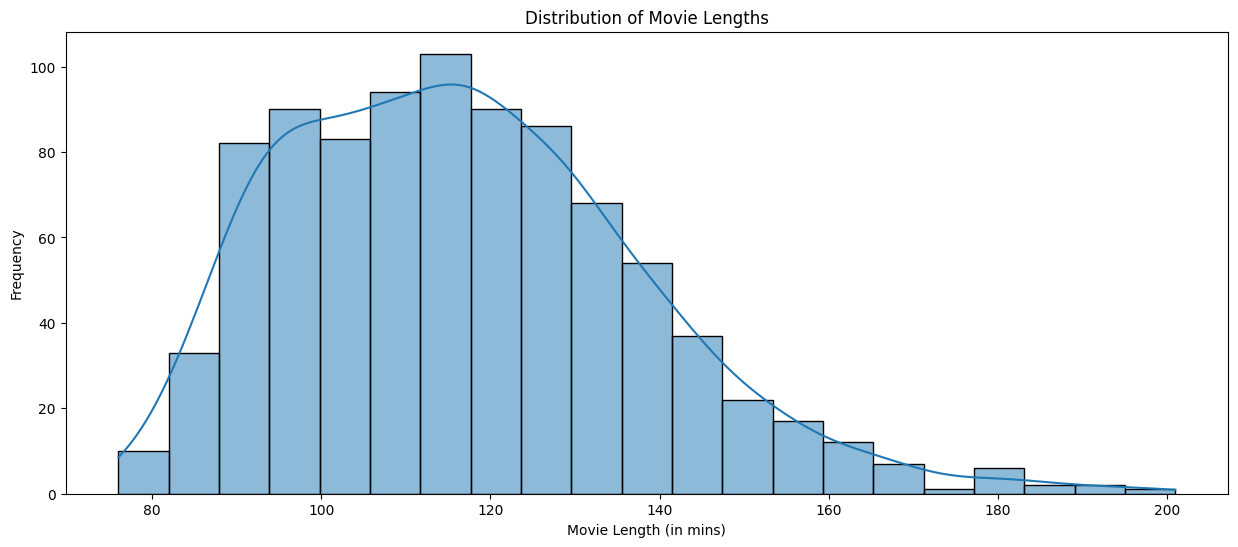

In [27]:
plt.figure(figsize=(15, 6))
sns.histplot(df['Movie Runtime (in mins)'], kde=True)
plt.title('Distribution of Movie Lengths')
plt.xlabel('Movie Length (in mins)')
plt.ylabel('Frequency')
plt.show()

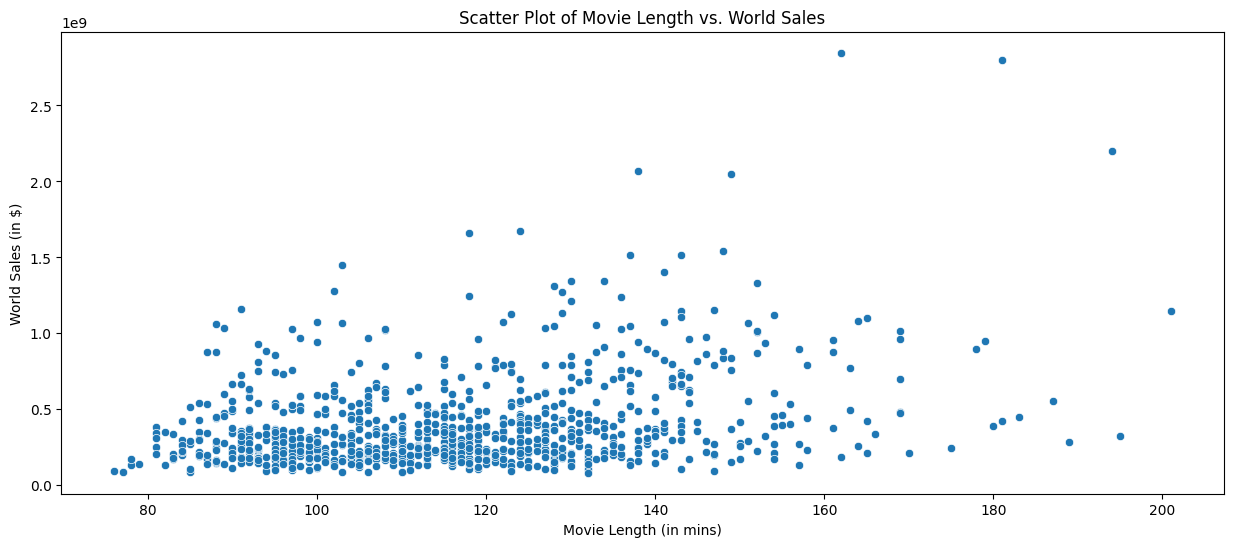

In [28]:
plt.figure(figsize=(15, 6))
sns.scatterplot(data=df, x='Movie Runtime (in mins)', y='World Sales (in $)')
plt.title('Scatter Plot of Movie Length vs. World Sales')
plt.xlabel('Movie Length (in mins)')
plt.ylabel('World Sales (in $)')
plt.show()

In [29]:
df['Dollar per Min (World)'] = df['World Sales (in $)']/df['Movie Runtime (in mins)']
df['Dollar per Min (Domestic)']= df['Domestic Sales (in $)']/df['Movie Runtime (in mins)']
df['Dollar per Min (International)'] = df['International Sales (in $)']/df['Movie Runtime (in mins)']

In [30]:
sorted_dpmW_df = df.sort_values('Dollar per Min (World)', ascending=False)
sorted_dpmW_df[['Title', 'Movie Runtime', 'Movie Runtime (in mins)', 'Dollar per Min (World)']].head(10)

,Title,Movie Runtime,Movie Runtime (in mins),Dollar per Min (World)
2,Avatar (2009),2 hr 42 min,162,1.757559e+07
1,Avengers: Endgame (2019),3 hr 1 min,181,1.545581e+07
0,Star Wars: Episode VII - The Force Awakens (2015),2 hr 18 min,138,1.499653e+07
11,The Lion King (2019),1 hr 58 min,118,1.409237e+07
17,Frozen II (2019),1 hr 43 min,103,1.407793e+07
4,Avengers: Infinity War (2018),2 hr 29 min,149,1.374738e+07
7,Jurassic World (2015),2 hr 4 min,124,1.347191e+07
61,Minions (2015),1 hr 31 min,91,1.274115e+07
39,Frozen (2013),1 hr 42 min,102,1.256380e+07
28,The Lion King (1994),1 hr 28 min,88,1.208650e+07


In [31]:
sorted_dpmD_df = df.sort_values('Dollar per Min (Domestic)', ascending=False)
sorted_dpmD_df[['Title', 'Movie Runtime', 'Movie Runtime (in mins)', 'Dollar per Min (Domestic)']].head(10)

,Title,Movie Runtime,Movie Runtime (in mins),Dollar per Min (Domestic)
0,Star Wars: Episode VII - The Force Awakens (2015),2 hr 18 min,138,6.787407e+06
7,Jurassic World (2015),2 hr 4 min,124,5.261174e+06
3,Black Panther (2018),2 hr 14 min,134,5.227064e+06
10,Incredibles 2 (2018),1 hr 58 min,118,5.157472e+06
16,Finding Dory (2016),1 hr 37 min,97,5.013356e+06
28,The Lion King (1994),1 hr 28 min,88,4.804361e+06
22,Shrek 2 (2004),1 hr 33 min,93,4.744368e+06
1,Avengers: Endgame (2019),3 hr 1 min,181,4.742392e+06
2,Avatar (2009),2 hr 42 min,162,4.694492e+06
17,Frozen II (2019),1 hr 43 min,103,4.634695e+06


In [32]:
sorted_dpmI_df = df.sort_values('Dollar per Min (International)', ascending=False)
sorted_dpmI_df[['Title', 'Movie Runtime', 'Movie Runtime (in mins)', 'Dollar per Min (International)']].head(10)

,Title,Movie Runtime,Movie Runtime (in mins),Dollar per Min (International)
2,Avatar (2009),2 hr 42 min,162,1.288110e+07
1,Avengers: Endgame (2019),3 hr 1 min,181,1.071342e+07
11,The Lion King (2019),1 hr 58 min,118,9.485266e+06
17,Frozen II (2019),1 hr 43 min,103,9.443236e+06
4,Avengers: Infinity War (2018),2 hr 29 min,149,9.191572e+06
61,Minions (2015),1 hr 31 min,91,9.048339e+06
113,Despicable Me 3 (2017),1 hr 29 min,89,8.653661e+06
39,Frozen (2013),1 hr 42 min,102,8.632893e+06
54,Furious 7 (2015),2 hr 17 min,137,8.484193e+06
7,Jurassic World (2015),2 hr 4 min,124,8.210732e+06


License Analysis

/tmp/ipython-input-2809027387.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=license_sales.index, y=license_sales.values, palette='viridis')


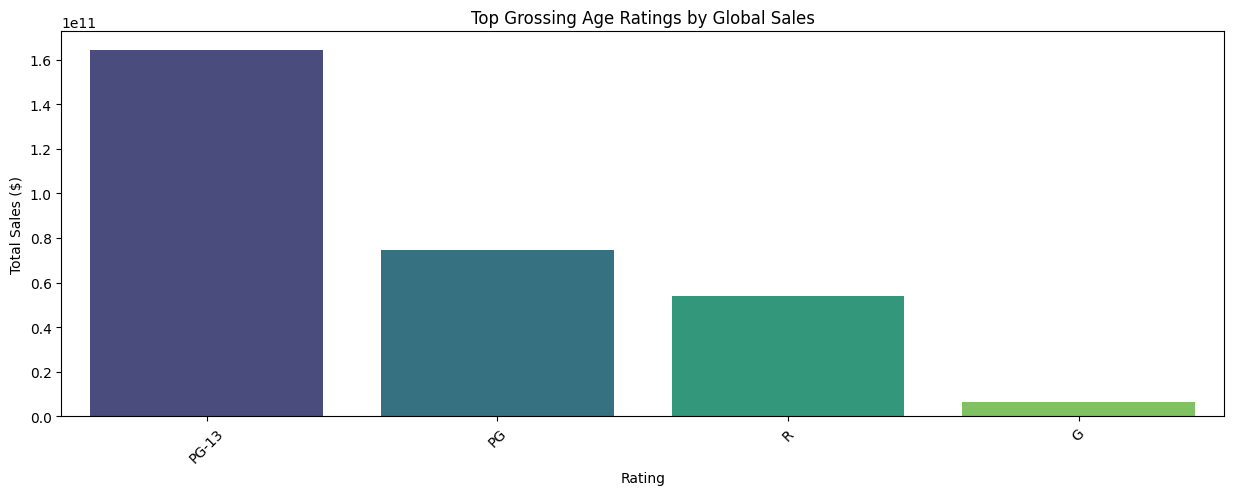

In [33]:

license_sales = df.groupby('License')['World Sales (in $)'].sum().sort_values(ascending=False)

plt.figure(figsize=(15, 5))
sns.barplot(x=license_sales.index, y=license_sales.values, palette='viridis')
plt.title('Top Grossing Age Ratings by Global Sales')
plt.xlabel('Rating')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.show()